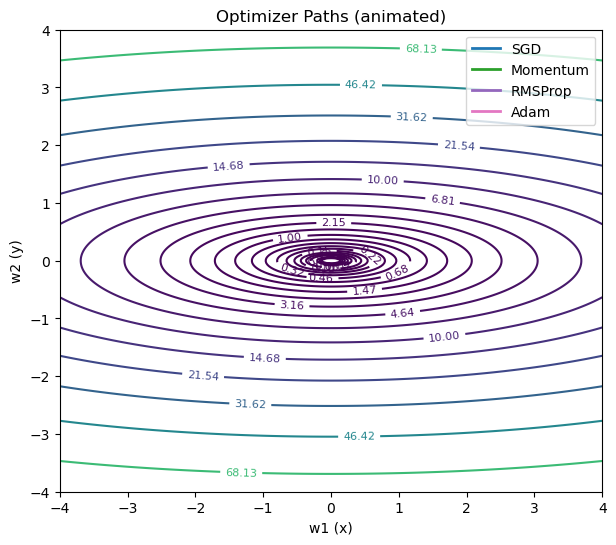

In [2]:
"""
Animated Optimizers Demo (SGD vs Momentum vs RMSProp vs Adam)

What you will SEE:
- A contour plot of a loss function (like hills on a map).
- Each optimizer starts at the same point and tries to reach the minimum (center).
- SGD often zig-zags.
- Momentum builds "velocity" and smooths the path.
- RMSProp adapts step size per-direction.
- Adam combines Momentum + RMSProp.

Run:
- In a Jupyter notebook: just run the cell.
- As a script: python optimizers_animation.py
"""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# ---------------------------
# 1) Loss function (a simple bowl)
#    Different curvature -> zig-zag problem
# ---------------------------
a = 1.0   # curvature in x direction
b = 10.0  # curvature in y direction (steeper)

def loss(w):
    # w = [x, y]
    x, y = w
    return 0.5 * (a * x**2 + b * y**2)

def grad(w):
    x, y = w
    return np.array([a * x, b * y])  # derivative of the loss

# ---------------------------
# 2) Optimizer update rules
# ---------------------------
def step_sgd(w, state, lr):
    g = grad(w)
    w = w - lr * g
    return w, state

def step_momentum(w, state, lr, beta=0.9):
    # v = beta*v + g
    g = grad(w)
    v = state.get("v", np.zeros_like(w))
    v = beta * v + g
    w = w - lr * v
    state["v"] = v
    return w, state

def step_rmsprop(w, state, lr, beta=0.9, eps=1e-8):
    # s = beta*s + (1-beta)*g^2
    g = grad(w)
    s = state.get("s", np.zeros_like(w))
    s = beta * s + (1 - beta) * (g**2)
    w = w - lr * g / (np.sqrt(s) + eps)
    state["s"] = s
    return w, state

def step_adam(w, state, lr, beta1=0.9, beta2=0.999, eps=1e-8):
    # m = beta1*m + (1-beta1)*g
    # v = beta2*v + (1-beta2)*g^2
    # bias correction: mhat = m/(1-beta1^t), vhat = v/(1-beta2^t)
    g = grad(w)
    m = state.get("m", np.zeros_like(w))
    v = state.get("v", np.zeros_like(w))
    t = state.get("t", 0) + 1

    m = beta1 * m + (1 - beta1) * g
    v = beta2 * v + (1 - beta2) * (g**2)

    mhat = m / (1 - beta1**t)
    vhat = v / (1 - beta2**t)

    w = w - lr * mhat / (np.sqrt(vhat) + eps)

    state["m"] = m
    state["v"] = v
    state["t"] = t
    return w, state

# ---------------------------
# 3) Simulation settings
# ---------------------------
start = np.array([3.5, 3.5])   # same starting point for all
steps = 120

# Learning rates (feel free to tweak)
lr_sgd = 0.12
lr_mom = 0.08
lr_rms = 0.08
lr_adam = 0.10

optimizers = {
    "SGD":      (step_sgd,      {"lr": lr_sgd}),
    "Momentum": (step_momentum, {"lr": lr_mom}),
    "RMSProp":  (step_rmsprop,  {"lr": lr_rms}),
    "Adam":     (step_adam,     {"lr": lr_adam}),
}

# Run all optimizers to record their paths
paths = {}
for name, (step_fn, kwargs) in optimizers.items():
    w = start.copy()
    state = {}
    path = [w.copy()]
    for _ in range(steps):
        w, state = step_fn(w, state, **kwargs)
        path.append(w.copy())
    paths[name] = np.array(path)

# ---------------------------
# 4) Make the contour plot (loss surface)
# ---------------------------
xx = np.linspace(-4, 4, 300)
yy = np.linspace(-4, 4, 300)
X, Y = np.meshgrid(xx, yy)
Z = 0.5 * (a * X**2 + b * Y**2)

fig, ax = plt.subplots(figsize=(7, 6))
levels = np.logspace(-2, 2, 25)  # nice looking levels
cs = ax.contour(X, Y, Z, levels=levels)
ax.clabel(cs, inline=True, fontsize=8)

ax.set_title("Optimizer Paths (animated)")
ax.set_xlabel("w1 (x)")
ax.set_ylabel("w2 (y)")
ax.set_xlim(-4, 4)
ax.set_ylim(-4, 4)

# Plot objects to update during animation
lines = {}
points = {}

for name in optimizers.keys():
    (line,) = ax.plot([], [], linewidth=2, label=name)
    (pt,) = ax.plot([], [], marker="o", markersize=6)
    lines[name] = line
    points[name] = pt

ax.legend(loc="upper right")

# ---------------------------
# 5) Animation function
# ---------------------------
def init():
    for name in optimizers.keys():
        lines[name].set_data([], [])
        points[name].set_data([], [])
    return list(lines.values()) + list(points.values())

def animate(frame):
    for name in optimizers.keys():
        p = paths[name][:frame+1]
        lines[name].set_data(p[:, 0], p[:, 1])
        points[name].set_data(p[-1, 0], p[-1, 1])
    ax.set_title(f"Optimizer Paths (step {frame}/{steps})")
    return list(lines.values()) + list(points.values())

ani = FuncAnimation(fig, animate, frames=steps+1, init_func=init, interval=60, blit=True)
plt.show()

# If you want to SAVE as GIF (optional), uncomment:
# (needs pillow installed: pip install pillow)
# ani.save("optimizers.gif", writer="pillow", fps=20)
